In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
delta_sales = pd.read_csv('DELTA_Q_Revenue.csv')

In [ ]:
display(delta_sales)

,Dates,"Delta Air Lines, Inc. (NYSE:DAL) - Total Revenue"
0,FQ3 2016,10.48b
1,FQ4 2016,9.46b
2,FQ1 2017,9.10b
3,FQ2 2017,10.75b
4,FQ3 2017,11.06b
5,FQ4 2017,10.23b
6,FQ1 2018,9.97b
7,FQ2 2018,11.78b
8,FQ3 2018,11.95b
9,FQ4 2018,10.74b


In [ ]:
delta_sales.rename(columns={'Delta Air Lines, Inc. (NYSE:DAL) - Total Revenue': 'delta_revenue'}, inplace=True)
display(delta_sales.head())

,Dates,delta_revenue
0,FQ3 2016,10.48b
1,FQ4 2016,9.46b
2,FQ1 2017,9.10b
3,FQ2 2017,10.75b
4,FQ3 2017,11.06b


In [ ]:
def fq_to_date(fq_str):
    # Split the string into quarter_label (e.g., 'FQ3') and year_str (e.g., '2016')
    quarter_label, year_str = fq_str.split(' ')

    year = int(year_str)

    # Assuming quarter_label is like 'FQ1', 'FQ2', 'FQ3', 'FQ4'
    # Extract the quarter number (e.g., 3 from 'FQ3')
    if quarter_label.startswith('FQ') and len(quarter_label) == 3:
        quarter = int(quarter_label[2])
    else:
        return pd.NaT # Handle unexpected quarter label format

    if quarter == 1:
        return pd.Timestamp(year, 3, 31) # End of Q1 is March 31
    elif quarter == 2:
        return pd.Timestamp(year, 6, 30) # End of Q2 is June 30
    elif quarter == 3:
        return pd.Timestamp(year, 9, 30) # End of Q3 is September 30
    elif quarter == 4:
        return pd.Timestamp(year, 12, 31) # End of Q4 is December 31
    else:
        return pd.NaT # Not a Time (for invalid quarters)

# Apply the function to the 'Dates' column to get actual end-of-quarter dates
delta_sales['Dates'] = delta_sales['Dates'].astype(str).apply(fq_to_date)

display(delta_sales.head())

,Dates,delta_revenue
0,2016-09-30,10.48b
1,2016-12-31,9.46b
2,2017-03-31,9.10b
3,2017-06-30,10.75b
4,2017-09-30,11.06b


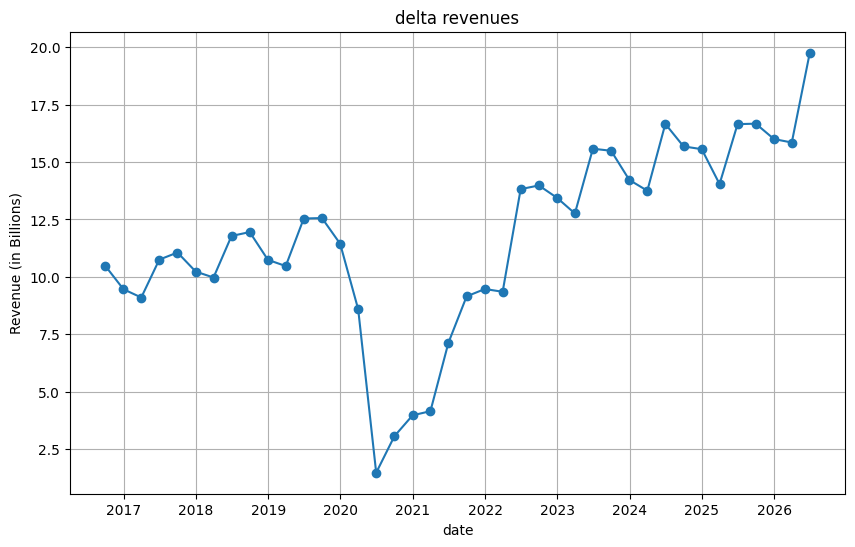

In [ ]:
# Convert 'delta_revenue' to a numeric type, handling 'b' for billions
delta_sales['delta_revenue'] = delta_sales['delta_revenue'].str.replace('b', '', regex=False).astype(float)

plt.figure(figsize=(10, 6))
plt.title('delta revenues')
plt.xlabel('date')
plt.ylabel('Revenue (in Billions)')

plt.plot(delta_sales['Dates'], delta_sales['delta_revenue'], marker='o')
plt.grid(True)
plt.show()

In [ ]:
# creating independent variable - time
# each row = 1 time peiod (day, q, year, etc)

delta_sales['time'] = range(1, len(delta_sales) + 1)
display(delta_sales)

,Dates,delta_revenue,time
0,2016-09-30,10.48,1
1,2016-12-31,9.46,2
2,2017-03-31,9.10,3
3,2017-06-30,10.75,4
4,2017-09-30,11.06,5
5,2017-12-31,10.23,6
6,2018-03-31,9.97,7
7,2018-06-30,11.78,8
8,2018-09-30,11.95,9
9,2018-12-31,10.74,10


In [ ]:
prediction_results = model1.get_prediction(x_test)
# 80% confidence level
prediction_results.summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
30,11.71,1.30,10.00,13.41,6.85,16.57
31,11.80,1.36,10.01,13.59,6.91,16.69
32,11.89,1.43,10.02,13.77,6.97,16.81
33,11.98,1.49,10.02,13.94,7.03,16.94
34,12.08,1.56,10.03,14.12,7.09,17.07
35,12.17,1.63,10.03,14.31,7.14,17.20
36,12.26,1.69,10.04,14.49,7.20,17.33
37,12.35,1.76,10.04,14.67,7.25,17.46
38,12.45,1.83,10.04,14.85,7.30,17.59
39,12.54,1.90,10.05,15.03,7.35,17.73


In [ ]:
# creating dummy variable for COVID period (March 11, 2020 - May 5, 2023)
start_date = pd.to_datetime('2020-03-11')
end_date = pd.to_datetime('2023-05-05')

delta_sales['covid_dv'] = np.where(
    (delta_sales['Dates'] >= start_date) & (delta_sales['Dates'] <= end_date),
    1,
    0
)
display(delta_sales)

,Dates,delta_revenue,time,covid_dv
0,2016-09-30,10.48,1,0
1,2016-12-31,9.46,2,0
2,2017-03-31,9.10,3,0
3,2017-06-30,10.75,4,0
4,2017-09-30,11.06,5,0
5,2017-12-31,10.23,6,0
6,2018-03-31,9.97,7,0
7,2018-06-30,11.78,8,0
8,2018-09-30,11.95,9,0
9,2018-12-31,10.74,10,0


In [ ]:
# Interaction term
delta_sales['covid_dv_interaction'] = delta_sales['time']*delta_sales['covid_dv']
display(delta_sales)

,Dates,delta_revenue,time,covid_dv,covid_dv_interaction
0,2016-09-30,10.48,1,0,0
1,2016-12-31,9.46,2,0,0
2,2017-03-31,9.10,3,0,0
3,2017-06-30,10.75,4,0,0
4,2017-09-30,11.06,5,0,0
5,2017-12-31,10.23,6,0,0
6,2018-03-31,9.97,7,0,0
7,2018-06-30,11.78,8,0,0
8,2018-09-30,11.95,9,0,0
9,2018-12-31,10.74,10,0,0


In [ ]:
delta_sales['q1_dv'] = np.where(delta_sales['Dates'].dt.quarter == 1, 1, 0)
display(delta_sales.head())

,Dates,delta_revenue,time,covid_dv,covid_dv_interaction,q1_dv
0,2016-09-30,10.48,1,0,0,0
1,2016-12-31,9.46,2,0,0,0
2,2017-03-31,9.10,3,0,0,1
3,2017-06-30,10.75,4,0,0,0
4,2017-09-30,11.06,5,0,0,0


In [ ]:
# Interaction term
delta_sales['q1_dv_interaction'] = delta_sales['time']*delta_sales['q1_dv']
display(delta_sales)

,Dates,delta_revenue,time,covid_dv,covid_dv_interaction,q1_dv,q1_dv_interaction
0,2016-09-30,10.48,1,0,0,0,0
1,2016-12-31,9.46,2,0,0,0,0
2,2017-03-31,9.10,3,0,0,1,3
3,2017-06-30,10.75,4,0,0,0,0
4,2017-09-30,11.06,5,0,0,0,0
5,2017-12-31,10.23,6,0,0,0,0
6,2018-03-31,9.97,7,0,0,1,7
7,2018-06-30,11.78,8,0,0,0,0
8,2018-09-30,11.95,9,0,0,0,0
9,2018-12-31,10.74,10,0,0,0,0


In [ ]:
# re-training and testing
dt4training = delta_sales[:int(0.75 * len(delta_sales))]
dt4testing = delta_sales[int(0.75 * len(delta_sales)):]

y2 = dt4training.loc[:,'delta_revenue']
x2 = dt4training.loc[:,['time','covid_dv','covid_dv_interaction','q1_dv','q1_dv_interaction']]
x2 = sm.add_constant(x2)

model2 = sm.OLS(y2,x2).fit()
model2.params

,0
const,9.49
time,0.19
covid_dv,-20.88
covid_dv_interaction,0.76
q1_dv,0.17
q1_dv_interaction,-0.04


In [ ]:
x_test = dt4testing.loc[:,'time']
x_test = sm.add_constant(x_test)

model2.predict(x_test)

,0
30,11.71
31,11.80
32,11.89
33,11.98
34,12.08
35,12.17
36,12.26
37,12.35
38,12.45
39,12.54


In [ ]:
model2.params

,0
const,9.49
time,0.19
covid_dv,-20.88
covid_dv_interaction,0.76
q1_dv,0.17
q1_dv_interaction,-0.04


In [ ]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          delta_revenue   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     19.27
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.06e-07
Time:                        20:13:33   Log-Likelihood:                -55.483
No. Observations:                  30   AIC:                             123.0
Df Residuals:                      24   BIC:                             131.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    9.4936      0.741     12.812      0.000       7.964      11.023
time                     0.1912      0.048      3.996      0.001       0.092       0.290
covid_dv               -20.8791      2.839     -7.355      0.000     -26.738     -15.020
covid_dv_interaction     0.7645      0.140      5.468      0.000       0.476       1.053
q1_dv                    0.1743      1.598      0.109      0.914      -3.123       3.471
q1_dv_interaction       -0.0387      0.096     -0.403      0.690      -0.237       0.159
==============================================================================
Omnibus:                       26.072   Durbin-Watson:                   2.142
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               56.211
Skew:                           1.819   Prob(JB):                     6.22e-13
Kurtosis:                       8.634   Cond. No.                         200.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import statsmodels.api as sm

# Check for missing values in 'delta_revenue'
missing_revenue_rows = delta_sales[delta_sales['delta_revenue'].isnull()]

if not missing_revenue_rows.empty:
    # If there are actual NaNs, predict them
    print(f"Found {len(missing_revenue_rows)} missing 'delta_revenue' values. Preparing to predict them:")
    display(missing_revenue_rows)

    required_features = ['time', 'covid_dv', 'covid_dv_interaction', 'q1_dv', 'q1_dv_interaction']

    if all(feature in missing_revenue_rows.columns for feature in required_features):
        x_predict_missing = missing_revenue_rows[required_features]
        x_predict_missing = sm.add_constant(x_predict_missing, has_constant='add')

        predicted_values = model2.predict(x_predict_missing)

        print("\nPredicted 'delta_revenue' values for the missing entries:")
        result_df = missing_revenue_rows.copy()
        result_df['predicted_delta_revenue'] = predicted_values
        display(result_df[['Dates', 'time', 'delta_revenue', 'predicted_delta_revenue']])
    else:
        print("Error: Not all required features for model prediction are available in the rows with missing 'delta_revenue'.")
        print(f"Required features for model2: {required_features}")
        print(f"Available features in rows with missing revenue: {missing_revenue_rows.columns.tolist()}")
elif 'dt4testing' in locals():
    # If no NaNs, but dt4testing exists, explain and predict for dt4testing with correct features.
    print("No explicit missing 'delta_revenue' values (NaNs) were found in the current 'delta_sales' DataFrame.")
    print("It appears that the previous prediction for the test set in cell `oCpOzVQofSy9` might have been inaccurate,")
    print("as the `x_test` DataFrame used there only included 'time' and 'const', while `model2` was trained with additional features.")
    print("\nHere's the corrected prediction for the test set (`dt4testing`) using all relevant features:")

    # Reconstruct x_test for prediction using all features model2 was trained on
    required_features = ['time', 'covid_dv', 'covid_dv_interaction', 'q1_dv', 'q1_dv_interaction']

    if all(feature in dt4testing.columns for feature in required_features):
        x_test_corrected = dt4testing[required_features]
        x_test_corrected = sm.add_constant(x_test_corrected, has_constant='add')

        predictions_dt4testing = model2.predict(x_test_corrected)

        # Combine original test data with predictions for comparison
        dt4testing_with_predictions = dt4testing.copy()
        dt4testing_with_predictions['predicted_delta_revenue'] = predictions_dt4testing

        print("\nTest set data with original and predicted 'delta_revenue':")
        display(dt4testing_with_predictions[['Dates', 'time', 'delta_revenue', 'predicted_delta_revenue']])

    else:
        print("Error: Not all required features for model prediction are available in the 'dt4testing' DataFrame.")
        print(f"Required features for model2: {required_features}")
        print(f"Available features in dt4testing: {dt4testing.columns.tolist()}")
else:
    print("No missing 'delta_revenue' values (NaNs) were found in the current 'delta_sales' DataFrame, and the 'dt4testing' DataFrame is not available. Please clarify which values you would like to predict.")

No explicit missing 'delta_revenue' values (NaNs) were found in the current 'delta_sales' DataFrame.
It appears that the previous prediction for the test set in cell `oCpOzVQofSy9` might have been inaccurate,
as the `x_test` DataFrame used there only included 'time' and 'const', while `model2` was trained with additional features.

Here's the corrected prediction for the test set (`dt4testing`) using all relevant features:

Test set data with original and predicted 'delta_revenue':


,Dates,time,delta_revenue,predicted_delta_revenue
30,2024-03-31,31,13.75,14.40
31,2024-06-30,32,16.66,15.61
32,2024-09-30,33,15.68,15.80
33,2024-12-31,34,15.56,16.00
34,2025-03-31,35,14.04,15.01
35,2025-06-30,36,16.65,16.38
36,2025-09-30,37,16.67,16.57
37,2025-12-31,38,16.00,16.76
38,2026-03-31,39,15.85,15.62
39,2026-06-30,40,19.76,17.14


### Predicting `delta_revenue` for the next 4 quarters (2026 Q3 to 2027 Q2)

In [ ]:
import pandas as pd
import numpy as np

# Define the next 4 quarters' end dates
future_quarters_dates = [
    pd.Timestamp('2026-09-30'), # 2026 Q3
    pd.Timestamp('2026-12-31'), # 2026 Q4
    pd.Timestamp('2027-03-31'), # 2027 Q1
    pd.Timestamp('2027-06-30')  # 2027 Q2
]

# Create a DataFrame for these future quarters
future_data = pd.DataFrame({'Dates': future_quarters_dates})

# Calculate 'time' variable for future quarters
last_time = delta_sales['time'].max()
future_data['time'] = range(last_time + 1, last_time + 1 + len(future_data))

# Calculate dummy variables and interaction terms for future quarters
start_date_covid = pd.to_datetime('2020-03-11')
end_date_covid = pd.to_datetime('2023-05-05')

future_data['covid_dv'] = np.where(
    (future_data['Dates'] >= start_date_covid) & (future_data['Dates'] <= end_date_covid),
    1,
    0
)
future_data['covid_dv_interaction'] = future_data['time'] * future_data['covid_dv']
future_data['q1_dv'] = np.where(future_data['Dates'].dt.quarter == 1, 1, 0)
future_data['q1_dv_interaction'] = future_data['time'] * future_data['q1_dv']

# Prepare the features for prediction
x_future = future_data[['time', 'covid_dv', 'covid_dv_interaction', 'q1_dv', 'q1_dv_interaction']]
x_future = sm.add_constant(x_future, has_constant='add')

# Predict 'delta_revenue' using model2
predicted_future_revenue = model2.predict(x_future)

# Add predictions to the future_data DataFrame
future_data['predicted_delta_revenue'] = predicted_future_revenue

print("Predicted 'delta_revenue' for the next 4 quarters:")
display(future_data[['Dates', 'time', 'covid_dv', 'q1_dv', 'predicted_delta_revenue']])

Predicted 'delta_revenue' for the next 4 quarters:


,Dates,time,covid_dv,q1_dv,predicted_delta_revenue
0,2026-09-30,41,0,0,17.33
1,2026-12-31,42,0,0,17.53
2,2027-03-31,43,0,1,16.23
3,2027-06-30,44,0,0,17.91
